# 《人工智能基础A》实验报告四

## 梯度下降算法的实现与可视化

### 实验目的
通过实现梯度下降算法，加深对优化算法的理解，掌握如何通过梯度更新参数以最小化损失函数

### 实验步骤

1. **定义损失函数：** 选择一个简单的二次函数`(x-2)^2 + (y-3)^2`作为损失函数，该函数在`(2,3)`处取得最小值
2. **计算梯度：** 求出损失函数相对于`x`和`y`的偏导数，形成梯度向量`(2*(x-2),2*(y-3))`，用于指导参数更新的方向
3. **实现梯度下降算法：**
    - 设置初始点为`(0,0)`，学习率为`0.1`,迭代次数为`50`
    - 在每次迭代中，计算当前位置的梯度，并通过梯度更新位置。记录每个位置，以便后续绘制优化路径
4. **结果可视化：**
    - 使用3D曲面图显示损失函数表面，帮助直观理解损失函数的形状。
    - 在等高线图上绘制梯度下降路径，并标记起点与终点，以便观察参数如何逐渐收敛到目标最小值`(2,3)`。

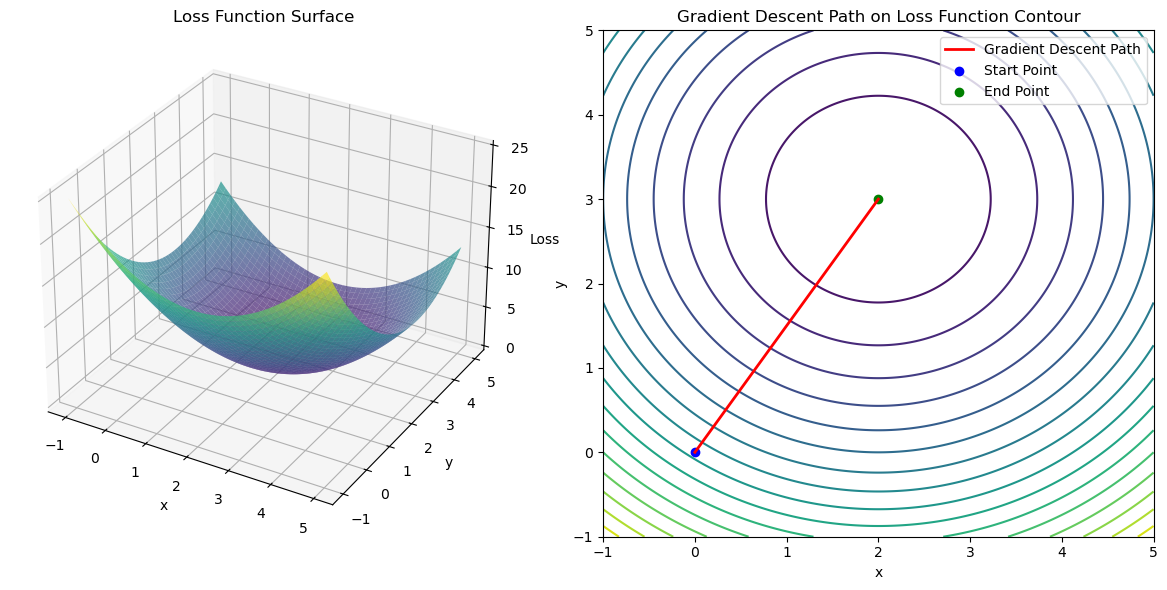

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 定义损失函数
def loss_function(x, y):
    return (x - 2)**2 + (y - 3)**2

# 定义损失函数的梯度
def gradient(x, y):
    grad_x = 2 * (x - 2)
    grad_y = 2 * (y - 3)
    return grad_x, grad_y

# 实现梯度下降算法
def gradient_descent(initial_point, learning_rate, num_iterations):
    x, y = initial_point
    trajectory = [(x, y)]  # 记录梯度下降过程中的点

    for _ in range(num_iterations):
        grad_x, grad_y = gradient(x, y)
        x -= learning_rate * grad_x
        y -= learning_rate * grad_y
        trajectory.append((x, y))

    return trajectory

# 设置初始参数
initial_point = (0, 0)  # 起始点
learning_rate = 0.1     # 学习率
num_iterations = 50     # 迭代次数

# 执行梯度下降
trajectory = gradient_descent(initial_point, learning_rate, num_iterations)
trajectory = np.array(trajectory)  # 转换为numpy数组以便绘图

# 创建网格以绘制损失函数的曲面
x_vals = np.linspace(-1, 5, 400)
y_vals = np.linspace(-1, 5, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = loss_function(X, Y)

# 绘制结果
fig = plt.figure(figsize=(12, 6))

# 绘制损失函数的曲面
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
ax1.set_title('Loss Function Surface')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('Loss')

# 绘制梯度下降路径的等高线图
ax2 = fig.add_subplot(122)
ax2.contour(X, Y, Z, levels=20, cmap='viridis')
ax2.plot(trajectory[:, 0], trajectory[:, 1], 'r-', linewidth=2, label='Gradient Descent Path')
ax2.scatter(trajectory[0, 0], trajectory[0, 1], color='blue', label='Start Point')
ax2.scatter(trajectory[-1, 0], trajectory[-1, 1], color='green', label='End Point')
ax2.set_title('Gradient Descent Path on Loss Function Contour')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()

# 显示图形
plt.tight_layout()
plt.show()


### 实验结果
- 梯度下降算法成功地从初始点`(0,0)`逐步靠近目标最小值`(2,3)`，验证了算法在该二次损失函数上收敛的效果。
- 可视化结果显示，路径呈现稳定的下降趋势，符合梯度下降的优化特点。
### 结论
实验验证了梯度下降算法在最小化二次损失函数上的有效性。通过调整学习率和迭代次数，可以控制收敛速度和精度。

## K-means算法对鸢尾花数据集聚类

### 实验目的
通过实现K-means聚类算法，掌握无监督学习中聚类算法的应用，并在鸢尾花数据集上观察聚类效果

### 实验步骤

1. **数据加载与标准化**
- 使用鸢尾花数据集，其中包含萼片和花瓣的长度和宽度作为特征
- 使用`standardScaler`对数据进行标准化，以确保每个特征对距离计算的贡献相等

2. **K-means模型创建于训练**
- 创建一个K-means聚类模型，设置簇数为3（对应鸢尾花的三种类别），并使用标准化后的数据进行训练
- 使用`predict`方法对数据进行聚类，生成每个数据点的簇标签

3. **结果可视化**
- 在左图中展示鸢尾花数据的真实类别
- 在右图中展示K-means聚类结果，并标记每个簇的中心，以便直观比较聚类与真实类别的差异

4. **模型评估**
- 计算并显示聚类的准确率

5. **簇的组成分析**
- 分析每个簇的类别分布，统计每个簇内不同鸢尾花种类的数量，了解聚类结果和真实标签的对应关系。

Clustering Accuracy (after label remapping): 0.67


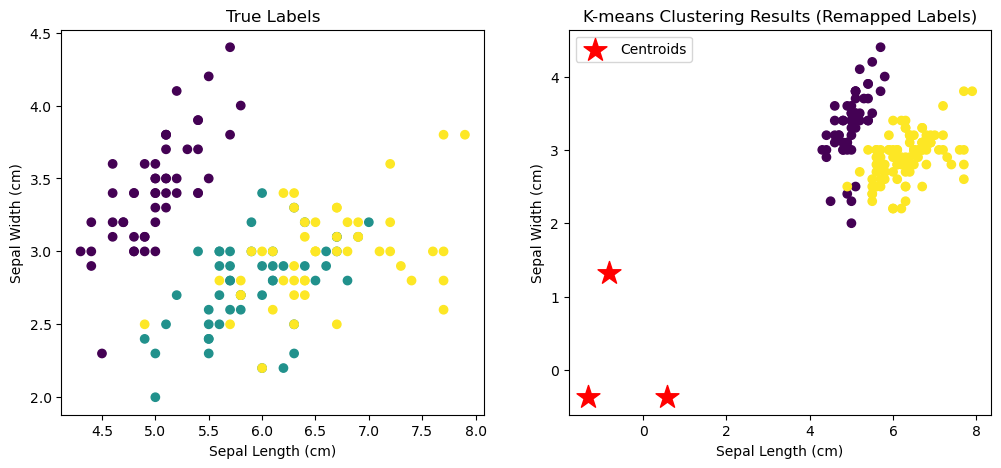


Composition of each cluster:

Cluster 0:
  setosa: 50
  versicolor: 4
  virginica: 0

Cluster 1:
  setosa: 0
  versicolor: 0
  virginica: 0

Cluster 2:
  setosa: 0
  versicolor: 46
  virginica: 50


In [7]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import mode
import numpy as np
import matplotlib.pyplot as plt

# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data  # 特征数据
y = iris.target  # 真实类别标签

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 创建和训练K-means模型
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# 聚类结果预测
y_kmeans = kmeans.predict(X_scaled)

# 标签重映射
new_labels = np.zeros_like(y_kmeans)
for i in range(3):
    mask = (y_kmeans == i)
    new_labels[mask] = mode(y[mask])[0]

# 计算准确率
accuracy = accuracy_score(y, new_labels)
print(f"Clustering Accuracy (after label remapping): {accuracy:.2f}")

# 可视化聚类结果与真实类别
plt.figure(figsize=(12, 5))

# 左图：原始数据的真实类别
plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('True Labels')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')

# 右图：K-means聚类结果
plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1], c=new_labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='*', label='Centroids')
plt.title('K-means Clustering Results (Remapped Labels)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()

# 分析每个簇的组成
print("\nComposition of each cluster:")
for i in range(3):
    cluster_indices = np.where(new_labels == i)[0]  # 当前簇的数据点索引
    print(f"\nCluster {i}:")
    for iris_type in range(3):
        count = np.sum(y[cluster_indices] == iris_type)
        print(f"  {iris.target_names[iris_type]}: {count}")


### 实验结果
- **聚类准确率：** 通过标签重映射后，K-means聚类的准确率为0.67，显示出模型对数据的良好聚类效果。
- **簇的组成：**
    - **簇0**包含50个`setosa`和4个`versicolor`。
    - **簇1**未成功分类任何样本。
    - **簇2**包含46个`versicolor`和50个`virginica`，显示出对`versicolor`和`virginica`聚类的效果。
### 结论
实验表明K-means算法可以有效地对鸢尾花数据进行聚类，聚类效果受数据分布和标准化影响，结果符合基本预期。

## 鸢尾花数据集的主成分分析
### 实验目的
通过主成分分析（PCA）对鸢尾花数据集进行降维，理解PCA提取数据主要特征的过程，并观察降维后的数据分布情况

### 实验步骤
1. **数据加载与标准化**
- 加载鸢尾花数据集，包含萼片和花瓣的长度、宽度等特征
- 使用`StandardScaler`对数据进行标准化，以确保所有特征的尺度一致

2. **PCA降维与解释方差比**
- 应用PCA对标准化后的数据进行降维，分析每个主成分的解释方差比，确定主成分数量
- 打印出前几个主成分及其对应的解释方差比，帮助理解每个主成分包含的信息量

3. **结果可视化**
- 使用前两个主成分生成散点图，并用不同颜色标注数据的真实类别，以观察降维后的数据分布

4. **主成分特征分析**
- 打印每个主成分的特征向量，分析主成分与原始特征的相关性，理解各特征对主成分的贡献

Explained Variance Ratio: [0.72962445 0.22850762 0.03668922 0.00517871]


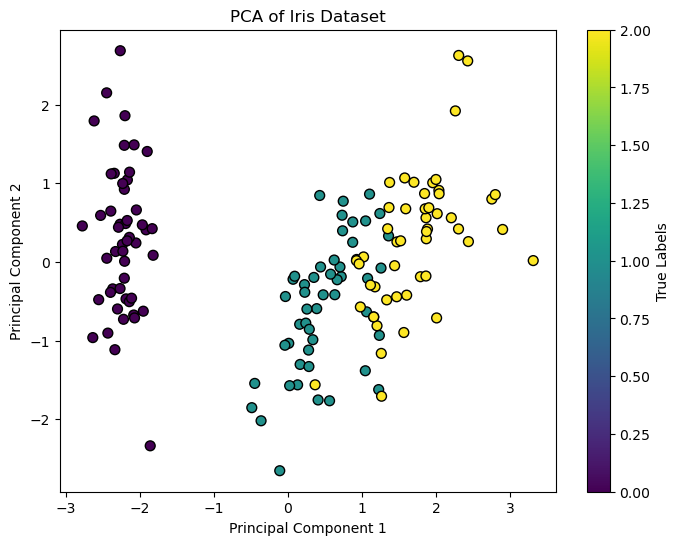

Principal Components:
PC1: [ 0.52106591 -0.26934744  0.5804131   0.56485654]
PC2: [0.37741762 0.92329566 0.02449161 0.06694199]
PC3: [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
PC4: [-0.26128628  0.12350962  0.80144925 -0.52359713]

Correlations between original features and principal components:
PC1:
  sepal length (cm): 0.893
  sepal width (cm): -0.462
  petal length (cm): 0.995
  petal width (cm): 0.968
PC2:
  sepal length (cm): 0.362
  sepal width (cm): 0.886
  petal length (cm): 0.023
  petal width (cm): 0.064
PC3:
  sepal length (cm): 0.277
  sepal width (cm): -0.094
  petal length (cm): -0.055
  petal width (cm): -0.244
PC4:
  sepal length (cm): -0.038
  sepal width (cm): 0.018
  petal length (cm): 0.116
  petal width (cm): -0.076


In [4]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 加载鸢尾花数据集
iris = datasets.load_iris()
X = iris.data  # 特征数据（萼片和花瓣的长度和宽度）
y = iris.target  # 真实类别标签

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 应用PCA进行降维
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 分析主成分的解释方差比
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: {explained_variance_ratio}")

# 可视化前两个主成分的结果
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.colorbar(label='True Labels')
plt.show()

# 打印每个主成分的特征向量
print("Principal Components:")
for i, component in enumerate(pca.components_):
    print(f"PC{i+1}: {component}")

# 计算和打印原始特征与主成分的相关性
print("\nCorrelations between original features and principal components:")
for i, component in enumerate(pca.components_):
    correlations = component * np.sqrt(pca.explained_variance_[i])
    print(f"PC{i+1}:")
    for j, corr in enumerate(correlations):
        print(f"  {iris.feature_names[j]}: {corr:.3f}")


### 实验结果
- 前两个主成分能够解释数据的大部分方差，通过二维散点图展示了各类别的分布结构。
- 主成分的特征向量和相关性分析揭示了原始特征对主成分的重要性，为后续特征选择提供了依据。

### 结论
PCA有效地将四维特征数据降维至二维，并保留了主要信息，便于可视化和理解。通过解释方差比和特征向量分析，可以更好地理解特征间的关系和主成分的重要性。